# Final Team Project

Work Division



1.   Section 1: Introduction and Data Loading: Lernik
2.   Section 2: Data Cleaning / Preparation: Tejasvika
3.   Section 3: Exploratory Data Analysis: Lernik
4.   Section 4: Model Selection: Tejasvika
5.   Section 5: Model Analysis: Lernik
6.   Section 6: Conclusion and Recommendations: Tejasvika



# Section 1: Introduction and Data Loading

Responsible Team Member: Lernik

1.   Load the Auto MPG dataset from the UCI Machine Learning Repository.
2.   Import the required libraries.



In [ ]:
!pip install ucimlrepo -q

import pandas as pd

from ucimlrepo import fetch_ucirepo

# Add additional required libraries below as the project develops.
import matplotlib.pyplot as plt







auto_mpg = fetch_ucirepo(id=9)

print("Auto MPG dataset loaded successfully.")

Auto MPG dataset loaded successfully.


3.   Display the number of rows and predictor columns.
4.   Display the predictor variable names and the target variable.
5.   Display the first 5 rows of the predictor data.
6.   Display the first 5 values of the target variable.



In [ ]:
X = auto_mpg.data.features
y = auto_mpg.data.targets

print("Number of rows:", X.shape[0])
print("Number of predictor columns:", X.shape[1])

print("\nPredictor variables:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.columns.tolist())

print("\nFirst 5 rows of predictor data:")
display(X.head())

print("\nFirst 5 values of target variable:")
display(y.head())

Number of rows: 398
Number of predictor columns: 7

Predictor variables:
['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']

Target variable:
['mpg']

First 5 rows of predictor data:


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1



First 5 values of target variable:


,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


We can see here that the "Auto MPG" dataset contains 398 rows and 7 predictor variables. The predictors are displacement, cylinders, horsepower, weight, acceleration, model year, and origin, while MPG is the target variable. The car name is not included as a predictor because it is mainly used as an identifier rather than a measurable vehicle characteristic. We may still use the car names later when we want to identify specific vehicles in the dataset.

# Section 2: Data Cleaning / Preparation
Responsible Team Member: Tejasvika

1.   Combine the predictor variables and the target variable into one dataset.
2.   Display the number of rows and columns in the combined dataset.
3.   Check each column for missing values.
4.   Check the dataset for duplicate rows.



In [ ]:
# Combining predictor and target variables
df = pd.concat([X, y], axis=1)

# Displaying dataset shape
print("Dataset shape:", df.shape)

# Checking missing values
missing_counts = df.isna().sum()
print("\nMissing values in each column:")
print(missing_counts)

# Counting repeated observations
duplicate_count = df.duplicated().sum()
print("\nDuplicate observations:", duplicate_count)

Dataset shape: (398, 8)

Missing values in each column:
displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

Duplicate observations: 0


Short explanation

5.   Identify which column contains missing values and display the rows where those values are missing.
6.   Examine the missing-value column using relevant summary statistics and related variables to determine how the missing values should be handled.



In [ ]:
# Identifying missing values column
missing_column = df.columns[df.isnull().any()]

print("Column with missing values:")
print(missing_column.tolist())

# Displaying rows w/ missing horsepower
missing_rows = df[df["horsepower"].isnull()]

print("\nRows with missing horsepower:")
display(missing_rows)

# Displaying horsepower summary statistics
print("\nHorsepower summary statistics:")
print(df["horsepower"].describe())

# Comparing horsepower by number of cylinders
print("\nHorsepower by number of cylinders:")
print(df.groupby("cylinders")["horsepower"].describe())

Column with missing values:
['horsepower']

Rows with missing horsepower:


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
32,98.0,4,NaN,2046,19.0,71,1,25.0
126,200.0,6,NaN,2875,17.0,74,1,21.0
330,85.0,4,NaN,1835,17.3,80,2,40.9
336,140.0,4,NaN,2905,14.3,80,1,23.6
354,100.0,4,NaN,2320,15.8,81,2,34.5
374,151.0,4,NaN,3035,20.5,82,1,23.0



Horsepower summary statistics:
count    392.000000
mean     104.469388
std       38.491160
min       46.000000
25%       75.000000
50%       93.500000
75%      126.000000
max      230.000000
Name: horsepower, dtype: float64

Horsepower by number of cylinders:
           count        mean        std   min     25%    50%    75%    max
cylinders                                                                 
3            4.0   99.250000   8.301606  90.0   95.25   98.5  102.5  110.0
4          199.0   78.281407  14.523099  46.0   68.00   78.0   88.0  115.0
5            3.0   82.333333  18.583146  67.0   72.00   77.0   90.0  103.0
6           83.0  101.506024  14.310472  72.0   92.50  100.0  110.0  165.0
8          103.0  158.300971  28.453552  90.0  140.00  150.0  175.0  230.0


Short explanation

7.   Remove the rows containing missing values.
8.   Display the number of rows and columns after cleaning.
9.   Confirm that no missing values remain in the cleaned dataset.



In [ ]:
# Removing rows with missing values
cleaned_df = df.dropna()

# Displaying rows and columns after cleaning
print("Dataset shape after cleaning:", cleaned_df.shape)

# Confirming no missing values remain
print("\nMissing values after cleaning:")
print(cleaned_df.isnull().sum())

Dataset shape after cleaning: (392, 8)

Missing values after cleaning:
displacement    0
cylinders       0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64


Short explanation

# Section 3: Exploratory Data Analysis

Responsible Team Member: Lernik

1.   Display descriptive statistics for the cleaned dataset.
2.   Create a histogram showing the distribution of MPG.
3.   Create a scatterplot comparing horsepower with MPG.
4.   Create a scatterplot comparing displacement with MPG.
5.   Create a scatterplot comparing weight with MPG.



,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,392.00,392.00,392.00,392.00,392.00,392.00,392.00,392.00
mean,194.41,5.47,104.47,2977.58,15.54,75.98,1.58,23.45
std,104.64,1.71,38.49,849.40,2.76,3.68,0.81,7.81
min,68.00,3.00,46.00,1613.00,8.00,70.00,1.00,9.00
25%,105.00,4.00,75.00,2225.25,13.78,73.00,1.00,17.00
50%,151.00,4.00,93.50,2803.50,15.50,76.00,1.00,22.75
75%,275.75,8.00,126.00,3614.75,17.02,79.00,2.00,29.00
max,455.00,8.00,230.00,5140.00,24.80,82.00,3.00,46.60


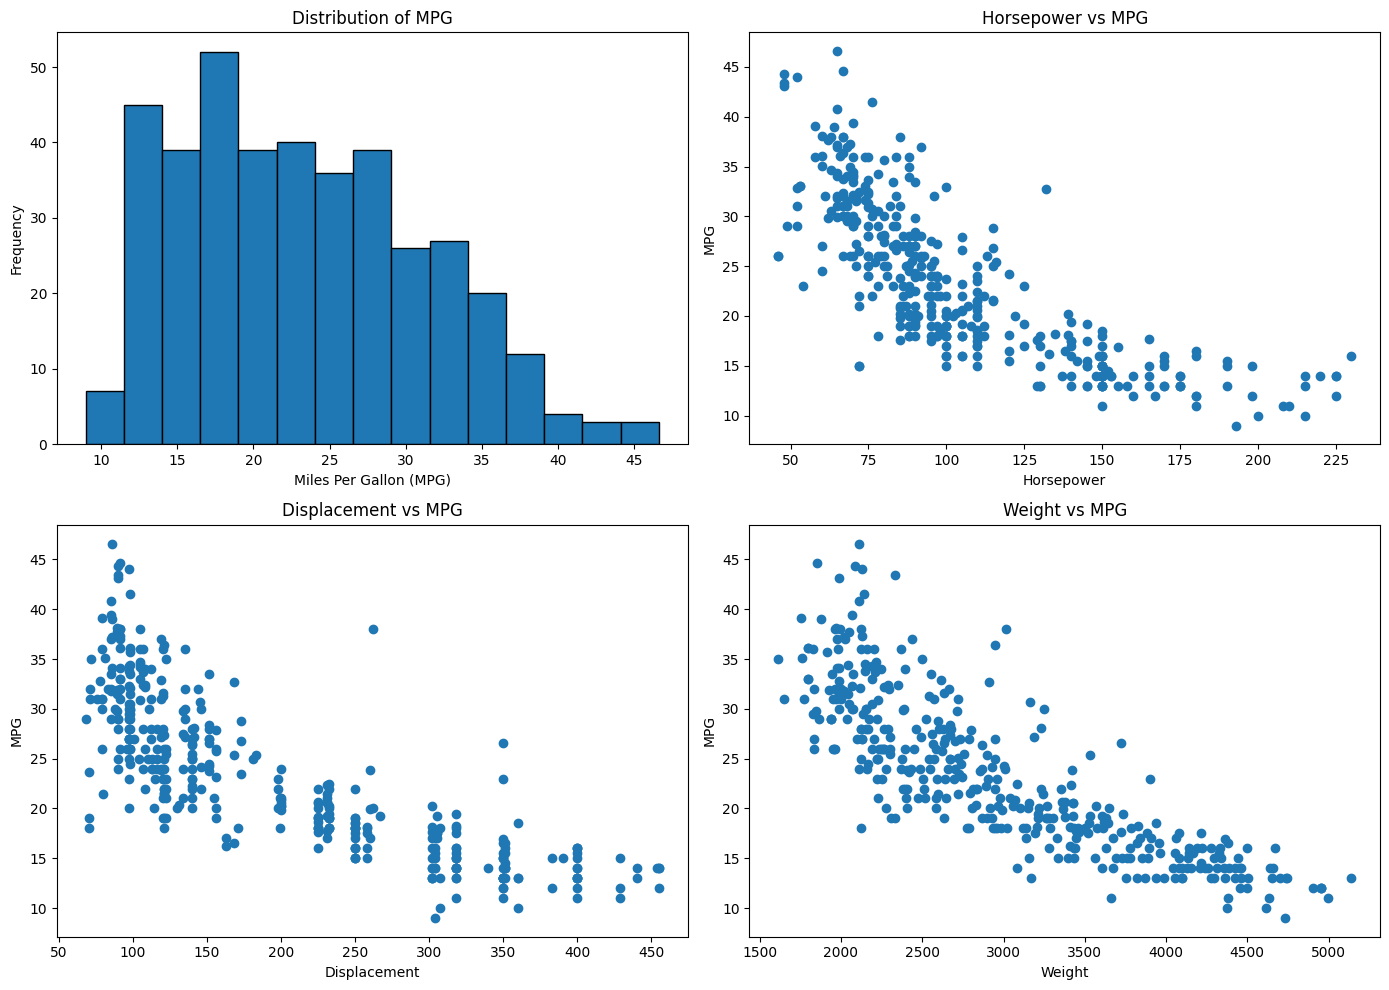

In [ ]:
display(cleaned_df.describe().round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(cleaned_df["mpg"], bins=15, edgecolor="black")
axes[0, 0].set_xlabel("Miles Per Gallon (MPG)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Distribution of MPG")

axes[0, 1].scatter(cleaned_df["horsepower"], cleaned_df["mpg"])
axes[0, 1].set_xlabel("Horsepower")
axes[0, 1].set_ylabel("MPG")
axes[0, 1].set_title("Horsepower vs MPG")

axes[1, 0].scatter(cleaned_df["displacement"], cleaned_df["mpg"])
axes[1, 0].set_xlabel("Displacement")
axes[1, 0].set_ylabel("MPG")
axes[1, 0].set_title("Displacement vs MPG")

axes[1, 1].scatter(cleaned_df["weight"], cleaned_df["mpg"])
axes[1, 1].set_xlabel("Weight")
axes[1, 1].set_ylabel("MPG")
axes[1, 1].set_title("Weight vs MPG")

plt.tight_layout()
plt.show()

Here we can see that the average MPG is about 23.45, and the values range from 9.00 to 46.60. Most of the cars fall somewhere in the lower to middle MPG range, while only a smaller number have very high MPG values. The scatterplots show that as horsepower, displacement, and weight increase, MPG usually decreases. Weight seems to show one of the clearest patterns, but all three variables appear to have a strong relationship with fuel efficiency.

6.   Calculate the correlation matrix for the cleaned dataset.
7.   Display the correlations between the numerical variables and MPG.
8.   Create a visualization of the correlation matrix.
9.   Create boxplots comparing MPG across cylinder counts and origin groups.
10.  Create a scatterplot comparing model year with MPG.

Correlation with MPG:


,mpg
mpg,1.00
model_year,0.58
origin,0.57
acceleration,0.42
cylinders,-0.78
horsepower,-0.78
displacement,-0.81
weight,-0.83


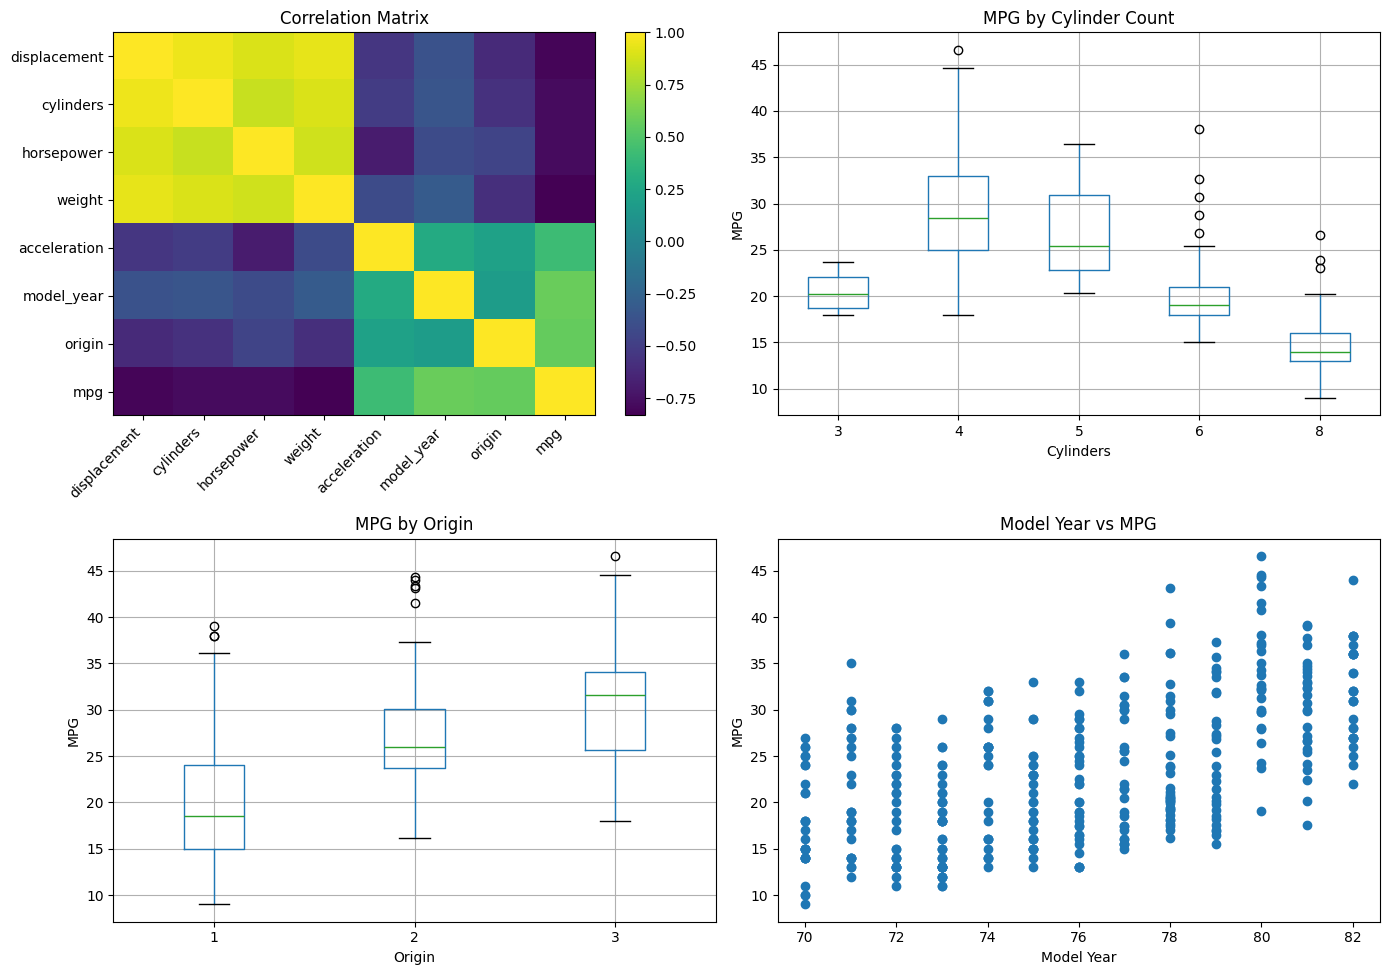

In [ ]:
correlation_matrix = cleaned_df.corr()

print("Correlation with MPG:")
display(
    correlation_matrix["mpg"]
    .sort_values(ascending=False)
    .round(2)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

im = axes[0, 0].imshow(correlation_matrix, aspect="auto")
axes[0, 0].set_xticks(range(len(correlation_matrix.columns)))
axes[0, 0].set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right",
)
axes[0, 0].set_yticks(range(len(correlation_matrix.columns)))
axes[0, 0].set_yticklabels(correlation_matrix.columns)
axes[0, 0].set_title("Correlation Matrix")

cleaned_df.boxplot(
    column="mpg",
    by="cylinders",
    ax=axes[0, 1],
)
axes[0, 1].set_xlabel("Cylinders")
axes[0, 1].set_ylabel("MPG")
axes[0, 1].set_title("MPG by Cylinder Count")

cleaned_df.boxplot(
    column="mpg",
    by="origin",
    ax=axes[1, 0],
)
axes[1, 0].set_xlabel("Origin")
axes[1, 0].set_ylabel("MPG")
axes[1, 0].set_title("MPG by Origin")

axes[1, 1].scatter(
    cleaned_df["model_year"],
    cleaned_df["mpg"],
)
axes[1, 1].set_xlabel("Model Year")
axes[1, 1].set_ylabel("MPG")
axes[1, 1].set_title("Model Year vs MPG")

fig.colorbar(im, ax=axes[0, 0])
plt.suptitle("")
plt.tight_layout()
plt.show()

Here we can see the same general pattern that appeared in the first set of plots. Weight has the strongest negative relationship with MPG, followed by displacement, horsepower, and cylinders. In other words, heavier cars and cars with larger or more powerful engines usually have lower MPG. Newer model years tend to have higher MPG, which also matches the upward pattern in the model year plot. The boxplots support these results too: cars with fewer cylinders generally have better MPG, and the origin groups also show noticeable differences. Since origin is a categorical variable, it makes more sense to compare the groups rather than interpret the numbers 1, 2, and 3 as a continuous scale.